# Install packages

In [1]:
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

In [2]:
# !pip install -qq numpy pandas nltk gensim tensorflow scikit-learn

# Import libraries

In [3]:
import re
import numpy as np
import pandas as pd
import nltk
import gensim.downloader as api
import tensorflow as tf

from nltk.corpus import gutenberg
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK Gutenberg corpus

In [4]:
nltk.download("gutenberg")

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


True

# Load a corpus

In [5]:
USE_CORPUS = "genesis"   # choose: "genesis" or "shakespeare"

if USE_CORPUS == "genesis":
    raw_text = gutenberg.raw("bible-kjv.txt")
elif USE_CORPUS == "shakespeare":
    shakespeare_files = [f for f in gutenberg.fileids() if "shakespeare" in f.lower()]
    raw_text = "\n".join([gutenberg.raw(f) for f in shakespeare_files])
else:
    raise ValueError("USE_CORPUS must be 'genesis' or 'shakespeare'")

print("Raw text length:", len(raw_text))

Raw text length: 4332554


# Clean the text

In [6]:
def clean_text(text, corpus_type="shakespeare"):
    text = text.lower()

    if corpus_type == "genesis":
        genesis_start = re.search(r"\bgenesis\b", text)
        exodus_start = re.search(r"\bexodus\b", text)
        if genesis_start and exodus_start and genesis_start.start() < exodus_start.start():
            text = text[genesis_start.start():exodus_start.start()]
        text = re.sub(r"\b\d+:\d+\b", " ", text)
        text = re.sub(r"\b\d+\b", " ", text)

    if corpus_type == "shakespeare":
        text = re.sub(r"\b[ivxlcdm]+\b", " ", text)
        text = re.sub(r"\b(act|scene|enter|exit|exeunt)\b", " ", text)
        text = re.sub(r"\b[a-z]{1,2}\.\b", " ", text)

    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\b[a-z]{1,2}\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

cleaned_text = clean_text(raw_text, corpus_type="shakespeare")

print(cleaned_text[:500])

the king james bible the old testament the king james bible the first book moses called genesis the beginning god created the heaven and the earth and the earth was without form and void and darkness was upon the face the deep and the spirit god moved upon the face the waters and god said let there light and there was light and god saw the light that was good and god divided the light from the darkness and god called the light day and the darkness called night and the evening and the morning wer


# Save the cleaned corpus

In [7]:
output_file = f"cleaned_{USE_CORPUS}.txt"

with open(output_file, "w", encoding="utf-8") as f:
    f.write(cleaned_text)

print("Saved:", output_file)

Saved: cleaned_genesis.txt


# Tokenise the corpus

In [8]:
MAX_VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts([cleaned_text])

word_index = tokenizer.word_index
total_words = min(MAX_VOCAB_SIZE, len(word_index) + 1)

print("Vocabulary size:", total_words)

Vocabulary size: 10000


# Convert text to token sequence

In [9]:
token_list = tokenizer.texts_to_sequences([cleaned_text])[0]
token_list = [t for t in token_list if t != 0]

print("Number of tokens:", len(token_list))
print("First 30 token ids:", token_list[:30])

MAX_TOKENS = 50000
token_list = token_list[:MAX_TOKENS]

print("\nNumber of tokens used:", len(token_list))

Number of tokens: 637045
First 30 token ids: [1, 39, 1245, 5938, 1, 210, 2553, 1, 39, 1245, 5938, 1, 187, 373, 104, 131, 8712, 1, 648, 18, 1268, 1, 141, 2, 1, 82, 2, 1, 82, 17]

Number of tokens used: 50000


# Build n-gram sequences

This is where the next-word prediction task is created.

Example:
+ input: in the beginning
+ target: god

In [10]:
MAX_SEQ_LEN = 20

input_sequences = []

for i in range(1, len(token_list)):
    start = max(0, i - MAX_SEQ_LEN)
    seq = token_list[start:i + 1]
    input_sequences.append(seq)

max_sequence_len = MAX_SEQ_LEN + 1

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding="pre"
)

xs = input_sequences[:, :-1]
labels = input_sequences[:, -1]
ys = np.array(labels)

print("X shape:", xs.shape)
print("y shape:", ys.shape)
print("Max sequence length:", max_sequence_len)

X shape: (49999, 20)
y shape: (49999,)
Max sequence length: 21


# Load GloVe embeddings from Gensim

In [11]:
glove_model = api.load("glove-wiki-gigaword-100")
EMBEDDING_DIM = glove_model.vector_size

print("Embedding dimension:", EMBEDDING_DIM)
print("Vector available for 'king':", "king" in glove_model)

[==================================================] 100.0% 128.1/128.1MB downloaded
Embedding dimension: 100
Vector available for 'king': True


# Build the embedding matrix

This aligns the loaded corpus vocabulary with the pretrained GloVe vectors.

In [12]:
total_words = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((total_words, EMBEDDING_DIM))

hits = 0
misses = 0

for word, idx in tokenizer.word_index.items():
    if idx >= total_words:
        continue

    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        misses += 1

print("Words found in GloVe:", hits)
print("Words not found in GloVe:", misses)

Words found in GloVe: 7129
Words not found in GloVe: 2870


# Build the next-word prediction model

This is the actual predictor.
GloVe is only the embedding initializer; the LSTM learns sequence behavior. Gensim's docs also distinguish standalone vectors in KeyedVectors from training a predictive neural model.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True
    ),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(128),
    Dropout(0.2),
    Dense(total_words, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_acc")
    ]
)

# Train the model

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    xs,
    ys,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.1171 - loss: 5.8848 - top5_acc: 0.2590 - val_accuracy: 0.1438 - val_loss: 6.4273 - val_top5_acc: 0.2686
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1580 - loss: 5.3616 - top5_acc: 0.2940 - val_accuracy: 0.1858 - val_loss: 6.4053 - val_top5_acc: 0.3268
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1810 - loss: 5.0492 - top5_acc: 0.3330 - val_accuracy: 0.1946 - val_loss: 6.4385 - val_top5_acc: 0.3328
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1969 - loss: 4.7815 - top5_acc: 0.3650 - val_accuracy: 0.2044 - val_loss: 6.4257 - val_top5_acc: 0.3466
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.2111 - loss: 4.5551 - top5_acc: 0.3902 - val_accuracy: 0.2072 - val_loss: 6.4641 - val_top5_acc: 0.3550
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.2192 - loss: 4.3607 - top5_acc: 0.4113 - val_accuracy: 0.2064 - va

# Plot training history

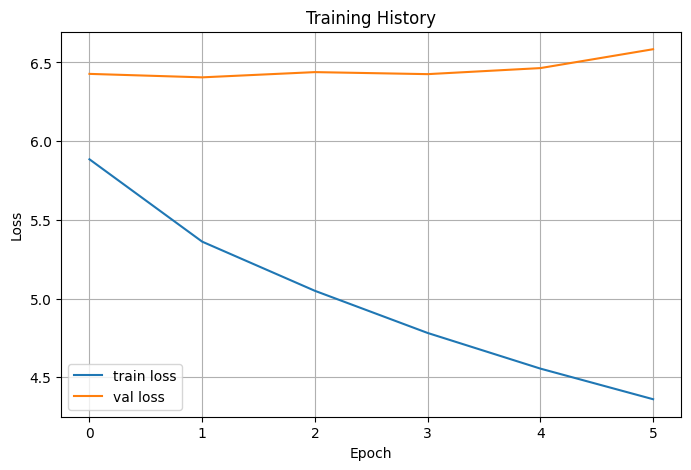

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(True)
plt.show()

# Function to predict the next word

In [16]:
COMMON_WORDS_GENESIS = {
    "the", "of", "to", "a", "in", "that", "with",
    "his", "her", "their", "my",
    "this", "for", "not", "but"
}

COMMON_WORDS_SHAKESPEARE = {
    "and", "the", "of", "to", "a", "in", "that", "with",
    "you", "his", "her", "their", "my", "thy", "thou",
    "this", "for", "not", "but", "shall",
    "is", "be", "was", "were"
}

COMMON_PENALTY_GENESIS = 0.6   # lighter penalty
COMMON_PENALTY_SHAKESPEARE = 0.35  # stronger penalty

if USE_CORPUS == "genesis":
    COMMON_WORDS = COMMON_WORDS_GENESIS
    COMMON_PENALTY = COMMON_PENALTY_GENESIS
elif USE_CORPUS == "shakespeare":
    COMMON_WORDS = COMMON_WORDS_SHAKESPEARE
    COMMON_PENALTY = COMMON_PENALTY_SHAKESPEARE

def top_k_sample(preds, k=5, temperature=0.6):
    preds = preds.copy()
    preds[0] = 0.0

    top_idx = np.argsort(preds)[-k:]
    filtered = np.zeros_like(preds)
    filtered[top_idx] = preds[top_idx]

    filtered = np.log(filtered + 1e-10) / temperature
    filtered = np.exp(filtered)
    filtered = filtered / np.sum(filtered)

    return np.random.choice(len(filtered), p=filtered)

def predict_next_word_better(
    seed_text,
    model,
    tokenizer,
    seq_len,
    generated_words=None,
    temperature=0.6,
    k=8,
    common_penalty=0.45,
    repeat_penalty=0.25
):
    import numpy as np
    import re
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    if generated_words is None:
        generated_words = []

    seed_text = seed_text.lower()
    seed_text = re.sub(r"[^a-z\s']", " ", seed_text)
    seed_text = re.sub(r"\s+", " ", seed_text).strip()

    token_ids = tokenizer.texts_to_sequences([seed_text])[0]
    token_ids = token_ids[-seq_len:]
    token_ids = pad_sequences([token_ids], maxlen=seq_len, padding="pre")

    preds = model.predict(token_ids, verbose=0)[0].astype("float64")
    preds[0] = 0.0

    # Penalize common words
    for word in COMMON_WORDS:
        idx = tokenizer.word_index.get(word)
        if idx is not None and idx < len(preds):
            preds[idx] *= common_penalty

    # Penalize recently generated words
    recent_words = generated_words[-3:]
    for word in recent_words:
        idx = tokenizer.word_index.get(word)
        if idx is not None and idx < len(preds):
            preds[idx] *= repeat_penalty

    # Top-k filter
    top_idx = np.argsort(preds)[-k:]
    filtered = np.zeros_like(preds)
    filtered[top_idx] = preds[top_idx]

    # Temperature
    filtered = np.log(filtered + 1e-10) / temperature
    filtered = np.exp(filtered)
    filtered = filtered / np.sum(filtered)

    next_index = np.random.choice(len(filtered), p=filtered)

    index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}
    return index_to_word.get(next_index, None)

# Generate multiple next words

In [17]:
def generate_text(
    seed_text,
    n_words,
    model,
    tokenizer,
    seq_len,
    temperature=0.6,
    k=8,
    common_penalty=0.45,
    repeat_penalty=0.25
):
    output = seed_text
    generated_words = []

    for _ in range(n_words):
        next_word = predict_next_word_better(
            output,
            model,
            tokenizer,
            seq_len,
            generated_words=generated_words,
            temperature=temperature,
            k=k,
            common_penalty=common_penalty,
            repeat_penalty=repeat_penalty
        )
        if next_word is None:
            break
        output += " " + next_word
        generated_words.append(next_word)

    return output

# Test the predictor

In [18]:
if USE_CORPUS == "genesis":
    seeds = [
        "in the beginning",
        "and god said",
        "the earth was",
        "and it came to pass"
    ]
else:
    seeds = [
        "to be or not",
        "my lord",
        "i love thee",
        "the king shall"
    ]

for seed in seeds:
    print("Seed:", seed)
    print("Prediction:", generate_text(seed,
                                       5,
                                       model,
                                       tokenizer,
                                       max_sequence_len,
                                       common_penalty=COMMON_PENALTY
                                       ))
    print()

Seed: in the beginning
Prediction: in the beginning and came the sons israel

Seed: and god said
Prediction: and god said him and the land israel

Seed: the earth was
Prediction: the earth was and the sons and they

Seed: and it came to pass
Prediction: and it came to pass and his children the lord



# Save the model

In [19]:
model_name = f"next_word_predictor_{USE_CORPUS}_glove.keras"
model.save(model_name)
print("Saved model:", model_name)

Saved model: next_word_predictor_genesis_glove.keras


# Save tokeniser metadata

In [20]:
import json

tokenizer_json = tokenizer.to_json()

with open(f"tokenizer_{USE_CORPUS}.json", "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

print("Tokenizer saved.")

Tokenizer saved.
